## Генераторы случайных чисел

![img](https://cdn.ablebits.com/_img-blog/random-generator/random-generator.png)

Желаемые свойства ГСЧ:
* моделирует равномерное распределение на [0, 1]
* проходит статистические тесты (какие?)
* высокая скорость работы
* большой период
* может работать на любом вычислительном устройстве
* воспроизводимость (а как же случайность?)
* криптографическая устойчивость (это не противоречит предыдущим требованиям?)

Генератор псевдослучайных чисел - это __алгоритм__ (!!!), который проходит статистические тесты.

### Middle-square algorithm
John von Neumann, 1949

Идея:
1. задаем четырехзначный seed - первое число случайной последовательности
2. возводим в квадрат, получаем 8-ми значное число (при необходимости, дополняем нулями)
3. берем четырехзначное число из середины - это следующий элемент случайной последовательности
4. повторяем 2-3

In [35]:
import numpy as np

def midsquare(val, n=4):
    return int(str(val**2).zfill(2*n)[n//2:-n//2])

seed = 5497
seq = [seed]
for _ in range(100):
    seq.append(midsquare(seq[-1]))
np.array(seq)

array([5497, 2170, 7089, 2539, 4465, 9362, 6470, 8609, 1148, 3179, 1060,
       1236, 5276, 8361, 9063, 1379, 9016, 2882, 3059, 3574, 7734, 8147,
       3736, 9576, 6997, 9580, 7764, 2796, 8176, 8469, 7239, 4031, 2489,
       1951, 8064,  280,  784, 6146, 7733, 7992, 8720,  384, 1474, 1726,
       9790, 8441, 2504, 2700, 2900, 4100, 8100, 6100, 2100, 4100, 8100,
       6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100,
       8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100,
       4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100,
       2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100,
       6100, 2100])

Может быть усложним алгоритм, добавив еще несколько операций?

```
… random numbers should not be
generated with a method chosen at
random. Some theory should be
used.
```
D. Knuth

### Linear congruential generator (LCG)

Linear congruential generator производит последовательность:
$$ z_{i+1} = (az_i + c) \mod m $$

Число $z_0$ называется *seed* и обеспечивает воспроизводимость последовательности “случайных” чисел.

Напишем функцию, которая реализует LCG (на практике чуть сложнее):

In [36]:
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

# setting the seed
rng.current = 1

Выведем несколько первых элементов последовательности:

In [37]:
[rng() for _ in range(10)]

[0.25693503906950355,
 0.5878706516232342,
 0.15432575810700655,
 0.767266943352297,
 0.9738139626570046,
 0.5858681506942958,
 0.8511155843734741,
 0.6132153405342251,
 0.7473867232911289,
 0.06236015981994569]

Как проверить, что последовательность действительно похожа на выборку из равномерного распределения?

Сделаем выборку побольше

In [38]:
samples = [rng() for _ in range(1000)]

В качестве первого шага построим гистограмму

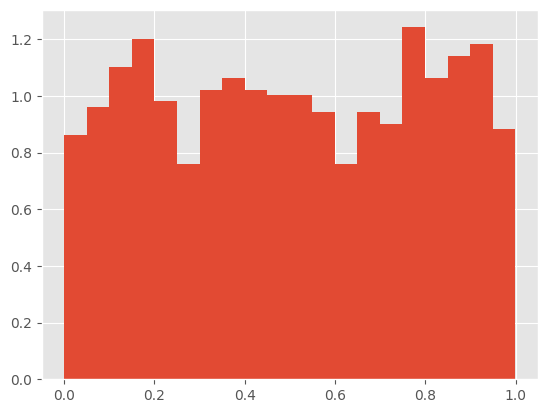

In [39]:
import matplotlib.pyplot as plt

fig = plt.figure()
fig.patch.set_facecolor('xkcd:white')
plt.hist(samples, bins=20, density=True)
plt.show()

На вид гистограммма не противоречит гипотезе о равномерности распределения, но нужны более точные количественные оценки. Их получают с помощью статистических тестов.

###Статистические тесты

Общая идея статистических тестов. Пусть мы хотим проверить гипотезу о том, что выборка Х принадлежит некоторому конкретному (совершенно конкретному) распределению F. Задача состоит в том, чтобы придумать такую статистику (функцию от выборки) T(X), которая в случае истинности нашей гипотезы будет иметь (при $n\to\infty$) наперед известное распределение, например N(0, 1). Посчитаем значение статистики Т=Т(Х) на нашей выборке. Если полученное число Т окажется крайне нетипичным для нормального N(0, 1) распределения, отвергнем гипотезу. Более точно, вычислим $p=P(|\xi|\ge|T|)$ для $\xi\sim N(0,1)$. Это число $p$ имеет специальное название: $p$-value. Если оно маленькое, например, меньше 0.05, то это повод отвергнуть гипотезу.

Далее обсудим конкретные тесты.


### Kolmogorov-Smirnov test

Проверяем гипотезу, что выборка получена из распределения F.
Вычисляем статистику
$$T(X) = \sup_x| F(x) - F_n(x)|,$$
где $F_n(x)$ - эмпирическая функция распределения, построенная по выборке Х объема n.
По сути, Т - это наибольшее расстояние между двумя графиками (см. картинку ниже).

Оказывается, что в случае истинности гипотезы, величина $ \sqrt{n}T$ имеет (в пределе больших n) особое распределение, которое называется [распределением Колмогорова](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%9A%D0%BE%D0%BB%D0%BC%D0%BE%D0%B3%D0%BE%D1%80%D0%BE%D0%B2%D0%B0).

Распределение Колмогорова является табличным, поэтому для любого значения статистики Т мы можем найти $p$-value и увидеть, будет оно маленьким или нет.

![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/KS_Example.png/450px-KS_Example.png)

На практике все делается одной строкой (проверяет гипотезу о принадлежности выбоки равномерному распределению ```stats.uniform.cdf```):

In [40]:
from scipy import stats

stats.kstest(samples, stats.uniform.cdf)

KstestResult(statistic=np.float64(0.026368738710880302), pvalue=np.float64(0.48207388563860043), statistic_location=np.float64(0.7513687387108803), statistic_sign=np.int8(-1))

Как интерпретировать результаты?

statistic=0.02636 - значение статистики (максимальное расстояние между графиками)

pvalue=0.48921 - pvalue для этого значения статистики. Видим, что pvalue > 0.05, так что мы решаем НЕ отвергать гипотезу о равномерном распределении.

Для сравнения, проверим гипотезу, что выборка порождена нормальным законом:

In [41]:
stats.kstest(samples, stats.norm.cdf)

KstestResult(statistic=np.float64(0.500866322716208), pvalue=np.float64(1.4724733582412854e-232), statistic_location=np.float64(0.00969158555381), statistic_sign=np.int8(-1))

Здесь pvalue крайне маленькое, и мы смело отвергаем гипотезу.

### Chi-squared test (Pearson's chi-squared test)

Один из самых популярных тестов. Снова проверяем гипотезу, что выборка (объема n) пришла из распределения F. Идея в том, чтобы разбить всю область определения случайной величины на К интервалов и в каждом интервале посчитать, сколько элементов выборки попало в данный интервал и сколько мы бы ожидали там увидеть, если бы выборка имела размер n и порождалась распределением F. Составляем статистику
$$\chi^2_{K-1}=\sum\limits_{i=1}^{K}\frac{(E_i-O_i)^2}{E_i}$$

$E_i, O_i$ - ожидаемые (expected) и наблюдаемые (observed) количества элементов выборки в i-ом интервале значений.

Рекомендуется выбирать K таким, чтобы $O_i, E_i \ge 5$.

Если гипотеза верна, то статистика критерия имеет (в пределе больших n) распределение хи-квадрат с К-1 степенью свободы.

Пример применения теста хи-квадрат:

In [42]:
k = 20
f_obs = np.histogram(samples, np.linspace(0, 1, k+1))[0]
f_exp = np.full(k, len(samples) // k)

f_obs, f_exp, stats.chisquare(f_obs, f_exp)

(array([42, 49, 55, 60, 49, 38, 51, 53, 51, 50, 50, 47, 38, 47, 45, 65, 50,
        60, 56, 44]),
 array([50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50]),
 Power_divergenceResult(statistic=np.float64(18.599999999999998), pvalue=np.float64(0.48275240319942647)))

Вывод - наблюдаемое значение статистики не противоречит гипотезе о равномерном распределении.

Проблема: последовательности ```sorted(samples)``` и ```samples``` неразличимы для KS и Chi2 тестов. Нужны дополнительные тесты.


### Serial test

Идея: разбить последовательность $x_1, x_2, x_3, ..., x_{2n}$ на последовательные серии длины 2: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ и посмотреть на каждый элемент как на случайную и независимую точку в 2D пространстве. Далее применить хи-квадрат. Аналогично, можно строить серии длины 3, 4 и т.д.

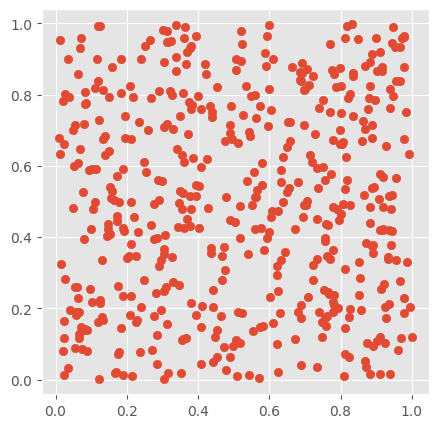

In [43]:
fig = plt.figure(figsize=(5, 5))
fig.patch.set_facecolor('xkcd:white')

plt.scatter(samples[::2], samples[1::2])
plt.axis('equal')
plt.show()

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import math

plt.style.use('ggplot')

### Задача 1*
Реализовать serial test и применить к выборке samples

In [45]:
def serial_test(samples, k=10):
    """
    samples: массив случайных чисел
    k: количество интервалов разбиения по каждой оси
    """
    n = len(samples)
    # Берем четное количество элементов для формирования пар
    if n % 2 != 0:
        samples = samples[:-1]
        n -= 1

    # Формируем пары
    pairs = samples.reshape(n // 2, 2)

    # Считаем попадания
    hist, xedges, yedges = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=k, range=[[0, 1], [0, 1]])

    # Ожидаемое количество в каждой ячейке
    expected = len(pairs) / (k ** 2)

    # Применяем тест хи квадрат
    chi2_stat, p_value = stats.chisquare(hist.flatten(), f_exp=expected)

    return chi2_stat, p_value

# Генерация выборки
samples = np.random.rand(1000)
chi2, p_val = serial_test(samples)

print(f"Задача 1 (Serial Test):")
print(f"Chi2 statistic: {chi2:.4f}, p-value: {p_val:.4f}")
if p_val > 0.05:
    print("Гипотеза о равномерности НЕ отвергается.")
else:
    print("Гипотеза о равномерности отвергается.")

Задача 1 (Serial Test):
Chi2 statistic: 88.4000, p-value: 0.7686
Гипотеза о равномерности НЕ отвергается.


### Permutation test

Снова разобъем последовательность $x_1, x_2, x_3, ..., x_{dn}$ на последовательные серии длины d: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), ..., (x_{nd-d}, x_{nd})$. Серия из d элементов может быть упорядочена d! способами и каждый способ упорядочивания равновероятен. Отсюда идея теста - посчитать, сколько раз каждый порядок встречается среди n серий и применить хи-квадрат тест.

### Задача 2*
Реализовать permutation test и применить к выборке samples

In [46]:
def permutation_test(samples, d=3):
    """
    samples: массив случайных чисел
    d: длина серии (размер перестановки)
    """
    n = len(samples)
    # Обрезаем выборку, чтобы она делилась на d
    m = n - (n % d)
    data = samples[:m].reshape(m // d, d)

    # Получаем индексы перестановок (например, [0.1, 0.5, 0.2] -> [0, 2, 1])
    # argsort возвращает индексы, которые отсортировали бы массив
    perms = np.argsort(data, axis=1)

    # Превращаем каждую перестановку в уникальный идентификатор (строку или число)
    # чтобы посчитать частоты
    perm_strings = [str(p) for p in perms]

    # Считаем наблюдаемые частоты
    from collections import Counter
    counts = Counter(perm_strings)

    # Всего возможных перестановок d!
    num_permutations = math.factorial(d)
    expected_count = (m // d) / num_permutations

    observed = []
    #  нужно учесть даже те перестановки, которые не встретились (частота 0)
    for p in counts.values():
        observed.append(p)

    # Если какие-то перестановки не выпали, нужно добавить нули
    if len(observed) < num_permutations:
        observed.extend([0] * (num_permutations - len(observed)))

    chi2_stat, p_value = stats.chisquare(observed, f_exp=expected_count)
    return chi2_stat, p_value

chi2_perm, p_val_perm = permutation_test(samples, d=4)

print(f"\nЗадача 2 (Permutation Test, d=4):")
print(f"Chi2 statistic: {chi2_perm:.4f}, p-value: {p_val_perm:.4f}")


Задача 2 (Permutation Test, d=4):
Chi2 statistic: 21.2960, p-value: 0.5630


Выбор параметров $m$, $a$ и $c$ существенно влияет на качество последовательности. Если параметры выбрать неудачно, это может привести к неожиданным последствиям:

In [47]:
def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m
rng_bad.current = 1

random = [rng_bad() for _ in range(30000)]
print("This sequence looks as random:")
random[:10]

This sequence looks as random:


[3.051897510886192e-05,
 0.00018310965970158577,
 0.0008239871822297573,
 0.003295936156064272,
 0.012359732296317816,
 0.04449496837332845,
 0.15573221957311034,
 0.533938602078706,
 0.8020416363142431,
 0.006802399177104235]

Гистограмма распределения похожа на равномерное:

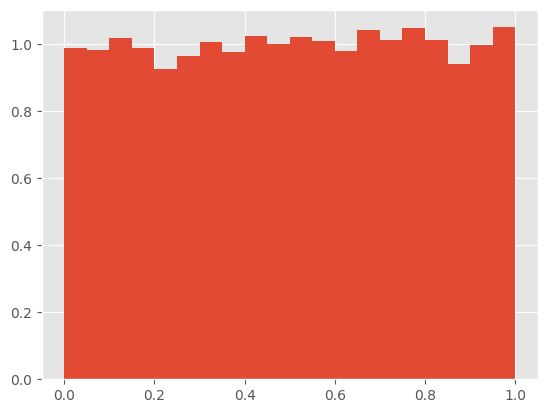

In [48]:
import matplotlib.pyplot as plt
fig = plt.figure()
fig.patch.set_facecolor('xkcd:white')

plt.hist(random, 20, density=True)
plt.show()

Однако, тест серий показывает, что точки располагаются на гиперплоскостях, что плохо согласуется с представлением о случайности:

In [49]:
import matplotlib
%matplotlib notebook
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(random[::3], random[1::3], random[2::3], s=1)
plt.show()

<IPython.core.display.Javascript object>

### Задача 3*

Привести статистический тест, который покажет, что с rng_bad есть проблемы, а с rng - нет.

In [50]:
# Реализация плохого генератора из ноутбука
def rng_bad_gen(n):
    m = 2**31
    a = 65539
    c = 0
    current = 1
    res = []
    for _ in range(n):
        current = (a * current + c) % m
        res.append(current / m)
    return np.array(res)

bad_samples = rng_bad_gen(30000)
chi2_bad, p_val_bad = serial_test(bad_samples, k=30) # k повыше

print(f"\nЗадача 3 (Проверка rng_bad Serial тестом):")
print(f"p-value: {p_val_bad}")
if p_val_bad < 1e-10:
    print("Serial Test уверенно отвергает гипотезу о случайности rng_bad (что и требовалось).")


Задача 3 (Проверка rng_bad Serial тестом):
p-value: 0.1888692402306393


Больше тестов на случайность - [Diehard tests](https://en.wikipedia.org/wiki/Diehard_tests).

Больше методов генерации равномерной величины [здесь](https://en.wikipedia.org/wiki/List_of_random_number_generators).

Сюжет про динамические системы и переход к хаосу https://www.youtube.com/watch?v=ovJcsL7vyrk&feature=youtu.be

## Генерация выборки из заданного распределения

Допустим, у нас есть генератор случайных числе из отрезка [0, 1] (используйте для этого функцию `np.random.rand()`). Как получить выборку из другого распределения $F$?



### Задача 4
Смоделировать выборку объема 1000 из дискретного распределения на множестве цифр 0, 1, 2, ..., 9 с весами 0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2. По выборке построить гистограмму. Оптимизируйте алгоритм, упорядочив веса.

In [51]:
elements = np.arange(10)
probabilities = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

probabilities /= probabilities.sum()

# Оптимизация
sorted_indices = np.argsort(probabilities)[::-1]
sorted_probs = probabilities[sorted_indices]
sorted_elements = elements[sorted_indices]

cumsum_probs = np.cumsum(sorted_probs)

N = 1000
u = np.random.rand(N)

#  ищем, в какой интервал попало u
indices = np.searchsorted(cumsum_probs, u)
generated_samples = sorted_elements[indices]

plt.figure(figsize=(10, 5))
plt.hist(generated_samples, bins=np.arange(11)-0.5, density=True, rwidth=0.8, alpha=0.7, label='Sampled')
plt.stem(elements, probabilities, linefmt='r-', markerfmt='ro', basefmt=' ', label='True PMF')
plt.xticks(elements)
plt.title("Задача 4: Дискретное распределение")
plt.legend()
plt.show()

<IPython.core.display.Javascript object>

### Inverse transform method

В следующем предложении заключается идея метода *inverse transform*:

Если $\xi$ имеет равномерное распределение в $[0,1]$, тогда $F^{-1}(\xi)$ распределена по закону $F$. (Для каких $F$ это верно?)

### Задача 5
Смоделируйте выборку размера 1000 из распределения $Exp(\lambda)$ с помощью метода Inverse transform. Постройте выборочную гистограмму и точный график плотности распределения.

In [52]:
lam = 1.0
N = 1000
u = np.random.rand(N)

# Обратное преобразование
exp_samples = -np.log(u) / lam

plt.figure(figsize=(10, 5))
plt.hist(exp_samples, bins=30, density=True, alpha=0.6, label='Sample Histogram')

x = np.linspace(0, 10, 100)
pdf = lam * np.exp(-lam * x)
plt.plot(x, pdf, 'r-', lw=2, label='True PDF')

plt.title("Задача 5: Экспоненциальное распределение")
plt.legend()
plt.show()

<IPython.core.display.Javascript object>

### Rejection sampling (Accept-reject method)

Идея метода: сэмплить из распределения, из которого умеем, а затем отбирать точки, которые следуют нужному распределению. Более точно: пусть умеем моделировать выборку из распределения с плотностью $p$, а хотим получить выборку из распределения с плотностью $\pi$. Возьмем случайный $x$ из распределения $p$. Затем возьмем $y$, равномерно распределенный на интервале $[0, p(x)]$. Если точка $(x, y)$ попала под график $\pi$, то примем $x$ за элемент выборки из $\pi$. Если нет - повторяем процедуру для нового $x$. Картинка иллюстрирует идею метода (плотности нормируются так, чтобы одна лежала целиком под другой):
<img src=https://colcarroll.github.io/hamiltonian_monte_carlo_talk/images/bayes_talk.015.png style="width: 50%;"/>


### Задача 6
Обоснуйте (устно), что метод accept-reject действительно производит выборку из нужного распределения. Смоделируйте 1000 точек из распределения с плотностью $e^xcos^2x$ на отрезке $[-\pi/2, \pi/2]$. По выборке постройте график выборочной гистограммы и сравните его с графиком точной функции плотности.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

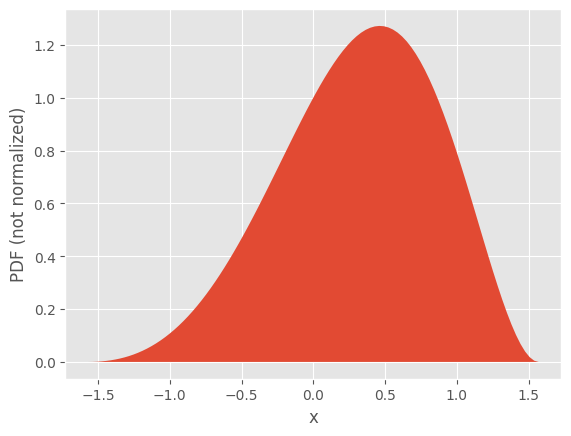

In [53]:
%matplotlib inline
fig = plt.figure()
fig.patch.set_facecolor('xkcd:white')

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x)*np.cos(x)**2
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.show()

Мы равномерно разбрасываем точки под графиком мажорирующей функции $M \cdot g(x)$. Точки, которые попадают под график целевой плотности $\pi(x)$, мы оставляем. Поскольку координата $Y$ точки выбирается равномерно от 0 до $M \cdot g(x)$, вероятность того, что она окажется ниже $\pi(x)$, пропорциональна $\pi(x)$. Следовательно, плотность распределения $X$-координат принятых точек будет пропорциональна $\pi(x)$

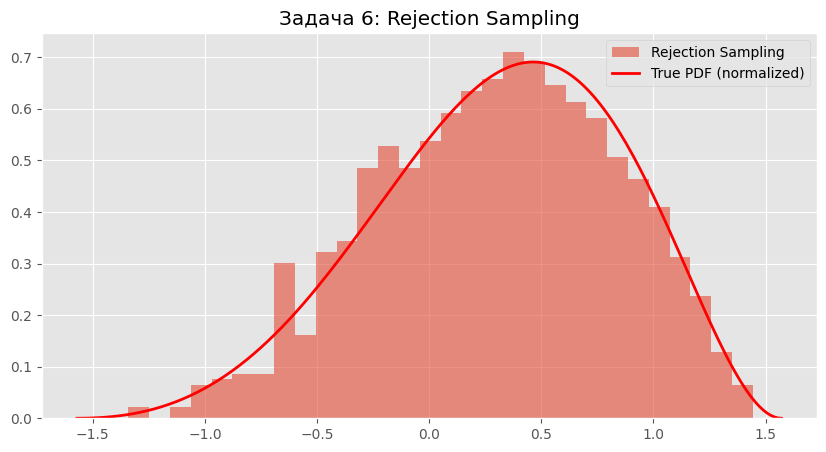

In [54]:
def target_density(x):
    return np.exp(x) * (np.cos(x)**2)

a, b = -np.pi/2, np.pi/2
M = 5.0

accepted_samples = []
N_needed = 1000

while len(accepted_samples) < N_needed:
    x_cand = np.random.uniform(a, b)
    y_cand = np.random.uniform(0, M)

    if y_cand <= target_density(x_cand):
        accepted_samples.append(x_cand)

accepted_samples = np.array(accepted_samples)

plt.figure(figsize=(10, 5))
plt.hist(accepted_samples, bins=30, density=True, alpha=0.6, label='Rejection Sampling')

x_vals = np.linspace(a, b, 200)
from scipy.integrate import quad
norm_const, _ = quad(target_density, a, b)
plt.plot(x_vals, target_density(x_vals) / norm_const, 'r-', lw=2, label='True PDF (normalized)')

plt.title("Задача 6: Rejection Sampling")
plt.legend()
plt.show()

##  Coordinate transformation method

Метод аccept-reject в ряде случаев может оказываться неэффективным и требовать слишком много пробных точек. Альтернатива -  попробовать найти преобразование координат, которое переводит простую область (из которой легко сэмплить, например, едининчный квадрат) в требуемую, но при этом сохраняет соотношение площадей (зачем?).

### Задача 7
Смоделировать и изобразить выборку из 500 точек равномерно распределенных внутри данного треугольника без использования метода отбора.

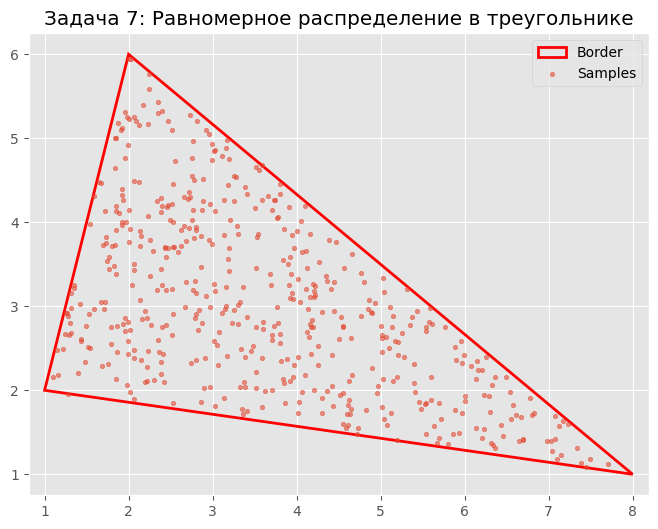

In [55]:
N = 500
# Генерация в параллелограмме
r1 = np.random.rand(N)
r2 = np.random.rand(N)

# Отражение точек, попавших за диагональ
mask = (r1 + r2 > 1)
r1[mask] = 1 - r1[mask]
r2[mask] = 1 - r2[mask]

# Вершины
A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

# Векторы
AB = B - A
AC = C - A

# Вычисление точек
P = A + np.outer(r1, AB) + np.outer(r2, AC)

plt.figure(figsize=(8, 6))
# Рисуем сам треугольник
polygon = plt.Polygon([A, B, C], fill=None, edgecolor='r', linewidth=2, label='Border')
plt.gca().add_patch(polygon)
plt.scatter(P[:, 0], P[:, 1], alpha=0.6, s=10, label='Samples')
plt.axis('equal')
plt.title("Задача 7: Равномерное распределение в треугольнике")
plt.legend()
plt.show()

### Задача 8
Смоделировать без использования метода отбора выборку из 500 точек равномерно распределенных внутри единичного круга. Изобразите полученные точки. Они действительно равномерно заполняют круг?

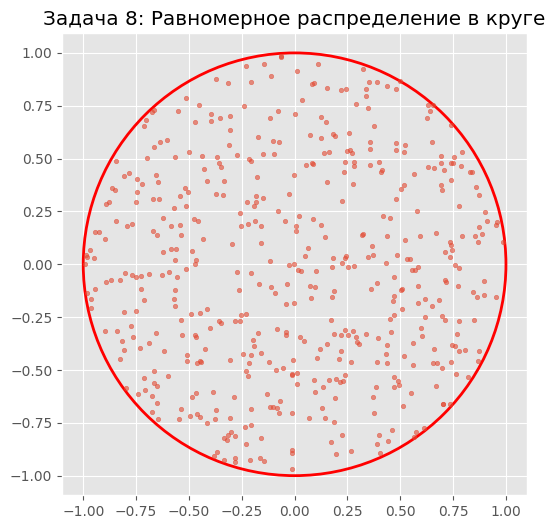

In [56]:
N = 500
u = np.random.rand(N)
phi = np.random.uniform(0, 2 * np.pi, N)

r = np.sqrt(u)  # корень для равномерности площади
x = r * np.cos(phi)
y = r * np.sin(phi)

plt.figure(figsize=(6, 6))
circle = plt.Circle((0, 0), 1, fill=None, color='r', linewidth=2)
plt.gca().add_patch(circle)
plt.scatter(x, y, s=10, alpha=0.6)
plt.axis('equal')
plt.title("Задача 8: Равномерное распределение в круге")
plt.show()

## Random normal generator

### Задача 9
Докажите (устно), что приведенный ниже алгоритм (Box-Muller algorithm) формирует выборку из независимых N(0,1) случаных величин. Модифицируйте метод, чтобы исключить вызовы тригонометрических функций ```np.sin``` и ```np.cos```. С помощью модифицированного метода смоделируйте выборку объема 1000 из двумерного гауссовского распределения со средним [4, 7] и ковариационной матрицей [[20,  -4],
       [ -4, 40]]. Постройте 2D гистограмму полученного распределения. Сравните выборочное среднее и ковариационную матрицу с точными значениями.

Часть 1: Доказательство: Рассмотрим совместную плотность двух независимых нормальных величин $X, Y \sim N(0, 1)$.$p(x, y) = \frac{1}{2\pi} e^{-(x^2+y^2)/2}$.Перейдем в полярные координаты: $x = r \cos \theta, y = r \sin \theta$. Якобиан перехода равен $r$.$p(r, \theta) = \frac{1}{2\pi} e^{-r^2/2} \cdot r$.Это распадается на $p(\theta) = \frac{1}{2\pi}$ (равномерное на $0..2\pi$) и $p(r) = r e^{-r^2/2}$.Случайная величина $R^2$ имеет показательное распределение с $\lambda=1/2$.Алгоритм Бокса-Мюллера генерирует именно эти величины из двух равномерных.Часть 2: Модификация: Чтобы избежать sin и cos, генерируем точку $(u, v)$ равномерно в круге $u^2+v^2 \le 1$ (метод отбора из квадрата $[-1, 1] \times [-1, 1]$).Тогда $S = u^2+v^2$.$x = u \sqrt{\frac{-2 \ln S}{S}}$, $y = v \sqrt{\frac{-2 \ln S}{S}}$.Часть 3: Двумерное распределениеНам нужно $\mathcal{N}(\mu, \Sigma)$.Алгоритм:Сгенерировать стандартный нормальный вектор $Z = (z_1, z_2)^T$.Найти матрицу $L$ такую, что $L L^T = \Sigma$.Искомый вектор $X = \mu + L Z$.


Задача 9 (2D Гаусс):
Истинное среднее: [4 7]
Выборочное среднее: [4.12379847 6.97656321]
Истинная ковариация:
 [[20 -4]
 [-4 40]]
Выборочная ковариация:
 [[19.80764277 -5.62239665]
 [-5.62239665 43.30869393]]


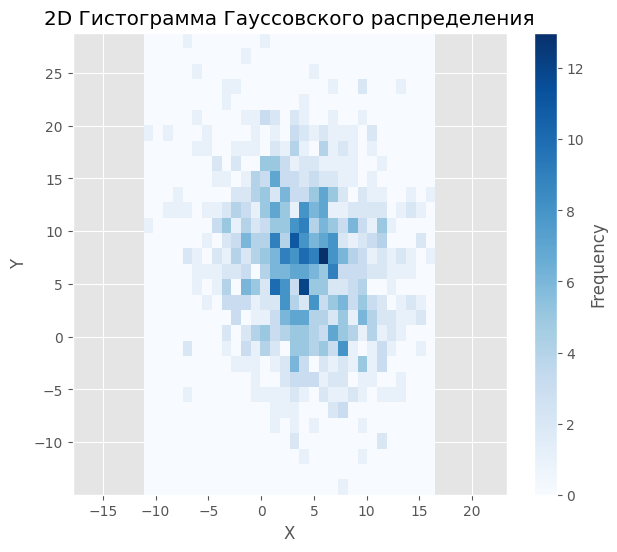

In [57]:
# 1. Полярный метод
def marsaglia_box_muller(n):
    res = []
    while len(res) < n:
        u, v = np.random.uniform(-1, 1, 2)
        s = u**2 + v**2
        if 0 < s <= 1:
            coef = np.sqrt(-2 * np.log(s) / s)
            res.append(u * coef)
            if len(res) < n:
                res.append(v * coef)
    return np.array(res)

# Генерируем 1000 точек (2 координаты для каждой, итого 2000 чисел)
z_vals = marsaglia_box_muller(2000).reshape(2, 1000)

# 2. Параметры распределения
mu = np.array([4, 7]).reshape(2, 1)
Sigma = np.array([[20, -4], [-4, 40]])

# 3. Разложение Холецкого
L = np.linalg.cholesky(Sigma)

# 4. Трансформация
# X = mu + L * Z
samples_2d = mu + L @ z_vals

x_data = samples_2d[0, :]
y_data = samples_2d[1, :]

print("\nЗадача 9 (2D Гаусс):")
print("Истинное среднее:", mu.flatten())
print("Выборочное среднее:", np.mean(samples_2d, axis=1))
print("Истинная ковариация:\n", Sigma)
print("Выборочная ковариация:\n", np.cov(samples_2d))

plt.figure(figsize=(7, 6))
plt.hist2d(x_data, y_data, bins=30, cmap='Blues')
plt.colorbar(label='Frequency')
plt.title("2D Гистограмма Гауссовского распределения")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.show()

### Задача 10*

Реализовать метод генерации случайного разбиения n-элементного множества на подмножества. С его помощью оценить ожидаемое число подмножеств в случайном разбиении множества из 100 элементов.

Подсказка 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Подсказка 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/